# Best Model Test Evaluation - YouTube Spam Detection

Evaluates the best model according to dev on the held-out test set.

## Setup

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)

from spam_ham_detector import BERTClassifier, CommentsDataset

sns.set_theme(style='whitegrid')

## Best model

In [2]:
BEST_EXPERIMENT = 'bert-distilbert-finetuned'
BEST_MODEL_NAME = 'distilbert-base-uncased'

dataset = CommentsDataset()

bert = BERTClassifier(model_name=BEST_MODEL_NAME)
bert.load()

y_true = dataset.y_test
y_pred = bert.predict(dataset.X_test)
y_scores = bert.predict_proba(dataset.X_test)[:, 1]

print(f'Experiment  : {BEST_EXPERIMENT}')
print(f'Test samples: {len(dataset.X_test)}')

Loading saved model...
Model loaded successfully.
Experiment  : bert-distilbert-finetuned
Test samples: 352


## Test Set Evaluation

### Classification report

In [3]:
print(classification_report(y_true, y_pred, target_names=['ham', 'spam']))

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       184
        spam       0.98      0.98      0.98       168

    accuracy                           0.98       352
   macro avg       0.98      0.98      0.98       352
weighted avg       0.98      0.98      0.98       352



### Confusion matrix

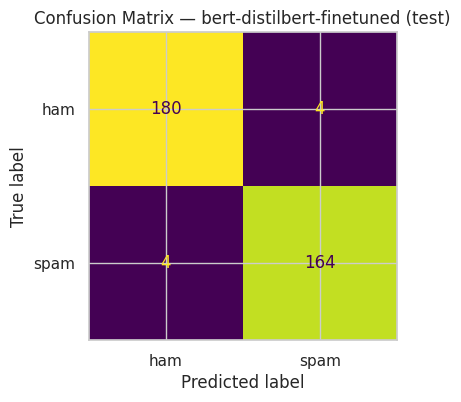

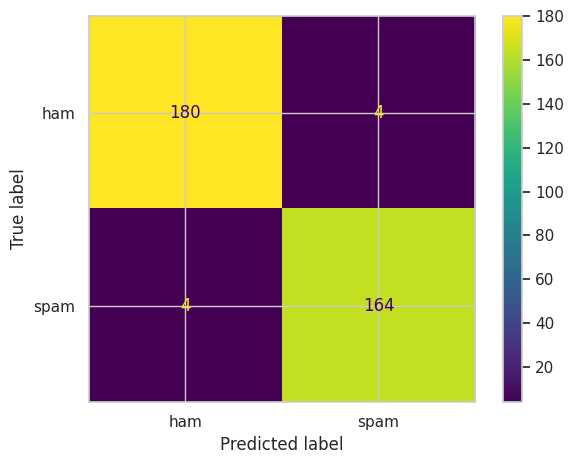

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))

disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=['ham', 'spam'])
disp.plot(ax=ax, values_format='d', colorbar=False)

ax.set_title(f'Confusion Matrix — {BEST_EXPERIMENT} (test)')
plt.tight_layout()
plt.show()

### ROC curve

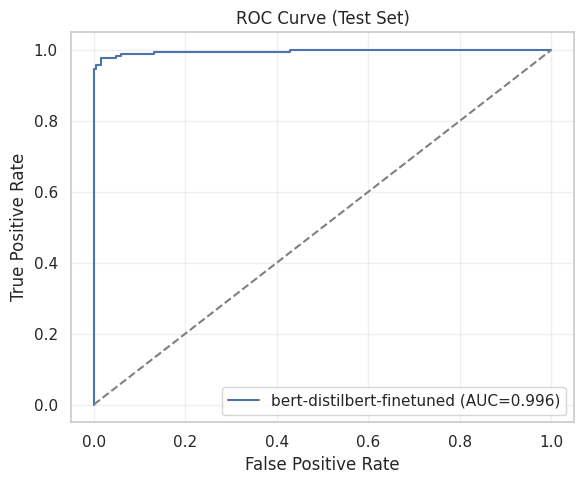

In [5]:
fpr, tpr, _ = roc_curve(y_true, y_scores)
auc = roc_auc_score(y_true, y_scores)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, label=f'{BEST_EXPERIMENT} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve (Test Set)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()